<a href="https://colab.research.google.com/github/Rebekah4256/The-Gaming-Industry-Capstone/blob/main/Capstone_Rebekah_Ryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # imports Pandas as pd
import numpy as np # imports numpy as np
from google.colab import auth #importing google account athenticate to connect google big query
auth.authenticate_user() # authenicateing google account
from google.cloud import bigquery #importing google big query connection
import matplotlib.pyplot as plt #import matplotlib as plt
import seaborn as sns # import seaborn as sns
from pandas_gbq import to_gbq # from pandas_gbq import to_gbq

In [ ]:
PROJECT_ID = 'capstone-2026-498917' #setting the big query project ID
client = bigquery.Client(project=PROJECT_ID) #connecting to google big query

In [ ]:
#selecting the game company data from the big query project
query = """
SELECT *
FROM `capstone-2026-498917.Data.Games`
"""
#creating the data frame
df = client.query(query).to_dataframe()

From the data, I would like to see how much the publishers made in the years covered, as well as whether the platform they released the games on would affect that. Another thing I want to see is how much gameplay you get for the game's release price. The last thing I want to figure out is how user reviews compare to critics' reviews, and whether the ESRB (Entertainment Software Rating Board) would make that difference.

First, I will need to get a feel for what the data looks like, so I will look at the first 10 rows.

In [ ]:
#the first 10 rows of the data
df.head(10)

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000010,Kirby's Knight,Atari 2600,Console,Atari,2,Platform,1990,2K Games,Epic Games,...,0,1,0,0,0,0,0,0,15.1,64.1
1,G000861,NHL 2026,Atari 2600,Console,Atari,2,Sports,1988,2K Games,2K Games,...,1,0,1,0,0,0,0,0,17.7,74.2
2,G001086,F-Zero Legacy,Atari 2600,Console,Atari,2,Racing,1988,2K Games,Humble Games,...,1,1,0,0,0,0,0,0,18.2,88.9
3,G002088,Dark Souls 3,Atari 2600,Console,Atari,2,Role-Playing,1992,2K Games,2K Games,...,0,1,0,0,0,0,0,0,43.8,158.4
4,G002580,God of War,Atari 2600,Console,Atari,2,Misc,1991,2K Games,2K Games,...,0,1,0,0,0,0,0,0,12.3,58.4
5,G002777,Batman: Arkham Valley,Atari 2600,Console,Atari,2,Action,1986,2K Games,2K Games,...,0,1,0,0,0,0,0,0,8.6,22.9
6,G002930,Dragon Quest III,Atari 2600,Console,Atari,2,Role-Playing,1991,2K Games,2K Games,...,0,1,1,0,0,0,0,0,47.0,214.2
7,G003839,Night in the Odyssey,Atari 2600,Console,Atari,2,Adventure,1986,2K Games,Nintendo,...,0,1,1,0,0,0,0,0,17.1,82.3
8,G005277,Portal 3,Atari 2600,Console,Atari,2,Puzzle,1985,2K Games,Capcom,...,0,1,0,0,0,0,0,0,9.5,36.0
9,G005422,Final Fantasy XVI,Atari 2600,Console,Atari,2,Role-Playing,1985,2K Games,2K Games,...,1,1,0,0,0,0,0,0,80.1,228.3


Next, I will look into whether there are any null values in the data and obtain a more complete list of column names.

In [ ]:
#checking for nulls and the data types in the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   game_id                             50000 non-null  object 
 1   title                               50000 non-null  object 
 2   platform                            50000 non-null  object 
 3   platform_type                       50000 non-null  object 
 4   platform_maker                      50000 non-null  object 
 5   platform_generation                 50000 non-null  Int64  
 6   genre                               50000 non-null  object 
 7   year                                50000 non-null  Int64  
 8   publisher                           50000 non-null  object 
 9   developer                           50000 non-null  object 
 10  publisher_region                    50000 non-null  object 
 11  publisher_tier                      50000

Looking at the data, there appear to be no nulls, but some column names could be shorter and easier to type while still conveying what is in the column, so I will rename those columns for ease of use.

In [ ]:
# renaming some of the columns as to make them easyer to type and remeber
df['na_sales_M'] = df['na_sales_million']
df['eu_sales_M'] = df['eu_sales_million']
df['jp_sales_M'] = df['jp_sales_million']
df['other_sales_M'] = df['other_sales_million']
df['estimate_sales_usd_M'] = df['estimated_revenue_million_usd']
df['global_sales_M'] = df['global_sales_million']
df['main_game_hrs'] = df['how_long_to_beat_main_hrs']
df['100%_hrs'] = df['how_long_to_beat_completionist_hrs']

Now that I have renamed and made copies of the columns, making them easy to use, I need to remove the old columns so as not to clutter the data frame.

In [ ]:
#dropping the duplicate columns that we renamed
df = df.drop(columns=['na_sales_million',
'eu_sales_million',
'jp_sales_million',
'other_sales_million',
'estimated_revenue_million_usd',
'global_sales_million',
'how_long_to_beat_main_hrs',
'how_long_to_beat_completionist_hrs'])

Now I'm triple-checking that there are no nulls in the data.

In [ ]:
#making sure all the renamed colmns are there and all the dups are gone
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   game_id               50000 non-null  object 
 1   title                 50000 non-null  object 
 2   platform              50000 non-null  object 
 3   platform_type         50000 non-null  object 
 4   platform_maker        50000 non-null  object 
 5   platform_generation   50000 non-null  Int64  
 6   genre                 50000 non-null  object 
 7   year                  50000 non-null  Int64  
 8   publisher             50000 non-null  object 
 9   developer             50000 non-null  object 
 10  publisher_region      50000 non-null  object 
 11  publisher_tier        50000 non-null  object 
 12  esrb_rating           50000 non-null  object 
 13  metacritic_score      50000 non-null  Int64  
 14  user_score            50000 non-null  float64
 15  critic_review_count

Now I'm making sure there are no duplicates in the data rows.

In [ ]:
#duble checking for nulls
df.isnull().sum()

,0
game_id,0
title,0
platform,0
platform_type,0
platform_maker,0
platform_generation,0
genre,0
year,0
publisher,0
developer,0


Now im makeing sure that there are so duplicates in the rows of the data

In [ ]:
#checking for duplicated data there seems to be none
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


Next, I'll get the count, mean, standard deviation, min, max, and quartile for all the data with numbers

In [ ]:
#describing the data to get a feel for the numbers
df.describe()

,platform_generation,year,metacritic_score,user_score,critic_review_count,user_review_count,launch_price_usd,is_sequel,online_multiplayer,dlc_released,...,goty_nominated,goty_won,na_sales_M,eu_sales_M,jp_sales_M,other_sales_M,estimate_sales_usd_M,global_sales_M,main_game_hrs,100%_hrs
count,50000.0,50000.0,50000.0,50000.000000,50000.0,50000.0,50000.000000,50000.0,50000.0,50000.0,...,50000.0,50000.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,4.39712,2007.47964,74.04648,7.407888,27.29016,470.6123,42.028854,0.4121,0.50696,0.62314,...,0.04464,0.00676,11.946759,7.732016,3.370298,2.985665,639.163523,26.034738,24.84839,87.036108
std,3.256757,11.673832,8.626383,1.160381,26.261779,894.567299,24.769804,0.492218,0.499957,0.484604,...,0.206514,0.081942,20.717035,13.477750,7.439700,5.634561,1103.970191,45.035430,34.73811,126.802256
min,0.0,1985.0,37.0,2.200000,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.030000,0.010000,0.000000,0.010000,0.000000,0.050000,1.00000,2.000000
25%,0.0,1998.0,68.0,6.600000,11.0,91.0,19.990000,0.0,0.0,0.0,...,0.0,0.0,2.420000,1.510000,0.400000,0.540000,92.590000,5.140000,9.00000,29.400000
50%,5.0,2008.0,74.0,7.400000,20.0,221.0,39.990000,0.0,1.0,1.0,...,0.0,0.0,5.940000,3.760000,1.210000,1.380000,294.835000,12.795000,13.20000,46.100000
75%,7.0,2017.0,80.0,8.200000,34.0,515.0,59.990000,1.0,1.0,1.0,...,0.0,0.0,13.420000,8.632500,3.330000,3.260000,750.355000,29.290000,24.10000,85.200000
max,10.0,2026.0,99.0,10.000000,636.0,39129.0,79.990000,1.0,1.0,1.0,...,1.0,1.0,769.070000,389.100000,251.210000,300.560000,45686.500000,1494.680000,377.50000,1685.000000


Now I'll start looking more into the actual data, starting by seeing how many games were released on each exact platform.

In [ ]:
#count of game per platform (the machines you can play the game on)
print(df.groupby('platform')['platform'].value_counts().sort_values(ascending=False))

platform
PC                   6305
NES                  3045
Mobile (iOS)         2622
Mobile (Android)     2483
Browser              2455
Game Boy             2107
SNES                 1906
Nintendo Switch      1737
PlayStation          1727
Atari 2600           1607
Sega Genesis         1555
PlayStation 2        1540
PlayStation 4        1492
PlayStation 3        1305
Xbox Series X/S      1300
Xbox 360             1289
Nintendo 3DS         1263
Nintendo DS          1260
PlayStation 5        1223
PSP                  1130
PlayStation Vita     1101
Game Boy Advance     1094
Xbox One             1043
Xbox                  991
Wii                   887
Nintendo 64           878
GameCube              796
Stadia                795
Game Boy Color        750
Sega Saturn           724
Wii U                 689
Dreamcast             498
Nintendo Switch 2     403
Name: count, dtype: int64


In this data, it would seem that most of the games were released on the PC, with the NES (Nintendo Entertainment System) console, released in 1986 is second, and the least is the Nintendo Switch 2, which makes sense because it is the newest released console.

Next, I would like to see how many games were released in each year.

In [ ]:
#how many games were relesed each year
print(df.groupby('year')['year'].value_counts().sort_values(ascending=False))

year
2011    1439
2019    1437
2026    1422
2010    1422
2020    1415
2023    1415
2017    1412
2013    1403
2025    1395
2016    1382
2015    1380
2024    1376
2014    1368
2012    1361
2021    1345
2022    1335
2018    1327
2007    1249
2003    1232
1999    1225
2001    1224
2002    1223
1998    1218
2000    1215
2008    1214
1997    1212
2009    1190
1996    1189
1995    1188
2004    1178
2006    1173
2005    1147
1989     883
1985     847
1994     838
1993     831
1986     826
1987     822
1990     820
1988     814
1991     804
1992     804
Name: count, dtype: Int64


So most games were released in 2011 and 2019, but surprisingly, the next is 2026, and it's only a few months into the year.

Another thing I would like to look into is the publishers' regions and the number of games they have published.

In [ ]:
#what region are the publishers and how many games they have published
print(df.groupby('publisher_region')['publisher'].value_counts())

publisher_region  publisher             
Austria           THQ Nordic                 702
Belgium           Larian Studios             778
Canada            Klei Entertainment         439
Denmark           Ghost Ship Games           396
Finland           Remedy Entertainment       709
France            Ubisoft                   1440
                  Focus Entertainment        744
                  Motion Twin                365
Germany           Deep Silver                736
Italy             505 Games                  727
Japan             Sega                      1560
                  Sony Interactive          1552
                  Bandai Namco              1536
                  FromSoftware              1520
                  Konami                    1484
                  Square Enix               1468
                  Nintendo                  1466
                  Capcom                    1456
Poland            CD Projekt                1417
Spain             Nomada Stu

Looking at the results, most publishers are from the US, and the next most are from Japan. And SAGA has published the most games.

Next, I would like to see which publisher made the most money globally.

In [ ]:
#How much each publisher made in total global sales in the millions
print(df.groupby('publisher')['global_sales_M'].sum().sort_values(ascending=False))

publisher
Sega                      59199.69
Nintendo                  58392.69
Sony Interactive          57556.85
Capcom                    56705.84
FromSoftware              56663.09
Square Enix               56513.43
Bandai Namco              54857.96
Konami                    53090.50
Insomniac Games           50060.11
id Software               49838.40
Take-Two Interactive      49272.29
Epic Games                49159.93
Activision Blizzard       49006.53
Bethesda Softworks        48668.89
2K Games                  48246.74
Warner Bros. Games        48140.65
Electronic Arts           46991.31
Valve                     46603.96
CD Projekt                46506.04
Ubisoft                   45677.74
Naughty Dog               45628.52
Bungie                    45200.78
Microsoft Studios         44643.65
Rockstar Games            44003.26
Obsidian Entertainment     6368.91
Paradox Interactive        6298.50
Larian Studios             6114.21
Remedy Entertainment       5833.76
Deep Silve

SEGA, Nintendo, and Sony Interactive have made the most globally,s and Motion Twin has made the least.

Next, I would like to see which game made the most and what made the least.

In [ ]:
#that title made the most in golbal sales
print(df.groupby('title')['global_sales_M'].sum().sort_values(ascending=False))

title
FIFA 2026                           8993.99
NHL 2023                            8404.92
MLB The Show 2026                   8081.25
MLB The Show 2024                   7542.42
PGA Tour 2023                       7345.91
                                     ...   
Frontier of the Chronicles             4.91
Realm of the Legend                    4.80
The Elder Scrolls IX: Eternal          4.75
City of the Knight                     4.32
The Elder Scrolls XI: Dark Below       1.20
Name: global_sales_M, Length: 1391, dtype: float64


FIFA 2026 made the most, and The Elder Scrolls XI: Dark Below made the least

Next, I'm looking at how long it would take, in hours, to reach 100% (complete everything there is to do in the game) in every game the developer made.

In [ ]:
#the count of titles that develper made and how long on total it would take to 100% all the games
print(df.groupby('developer').agg({'title':'count','100%_hrs':'sum'}).sort_values(by= '100%_hrs', ascending=False))

                        title  100%_hrs
developer                              
Sega                     1355  121477.0
Bandai Namco             1308  118314.1
FromSoftware             1316  116998.2
Konami                   1291  116956.8
Sony Interactive         1334  116367.7
Electronic Arts          1284  115486.9
Capcom                   1249  113176.8
Nintendo                 1275  112820.8
Take-Two Interactive     1276  109496.8
id Software              1339  109421.1
Activision Blizzard      1252  109077.4
Microsoft Studios        1236  108631.8
Square Enix              1210  108285.2
Bungie                   1263  108254.6
Epic Games               1309  108052.0
Warner Bros. Games       1223  107746.5
Insomniac Games          1292  107411.9
Valve                    1321  106990.8
Bethesda Softworks       1287  105730.4
Naughty Dog              1271  105500.5
CD Projekt               1243  104752.3
Rockstar Games           1215  102831.5
2K Games                 1210  101197.0


To 100% all of the games SEGA has ever made, it would take 121477 hours, or 5061 days, or almost 14 years

Next, I wanted to see which developer had the longest average time to 100% one of their games.

In [ ]:
#how many titles the develpers made and the average time it would take to 100% the games they made
print(df.groupby('developer').agg({'title':'count','100%_hrs':'mean'}).sort_values(by= '100%_hrs', ascending=False))

                        title    100%_hrs
developer                                
Coffee Stain              637  100.757457
Paradox Interactive       808   97.913119
Larian Studios            857   96.326838
tinyBuild                 617   95.434198
Other                     608   93.318586
Motion Twin               619   93.129079
Chucklefish               629   90.632591
Capcom                   1249   90.613931
Konami                   1291   90.593958
Bandai Namco             1308   90.454205
Annapurna Interactive     599   90.292988
Electronic Arts          1284   89.943069
Sega                     1355   89.650923
Square Enix              1210   89.491901
Nomada Studio             616   89.222403
Team17                    802   89.019950
FromSoftware             1316   88.904407
505 Games                 831   88.758363
Nintendo                 1275   88.486902
Klei Entertainment        625   88.459040
Focus Entertainment       842   88.276366
Obsidian Entertainment    865   88

Coffee Stain has, on average, the longest games to 100% at 100 hours on average, and Unknown Worlds has the shortest at 79 hours.

Next, I want to see how much, on average, a game costs on the console it was released on, how much the games made globally, how many hours it would take to 100% it, and how many consoles were released.

In [ ]:
#Number of titles per platform and average time it would take to 100% the average game and launch price in usd and total global sales.
print(df.groupby('platform').agg({'title':'count','100%_hrs':'mean', 'global_sales_M': 'sum', 'launch_price_usd': 'mean'}).sort_values(by= 'global_sales_M', ascending=False))

                   title   100%_hrs  global_sales_M  launch_price_usd
platform                                                             
Mobile (iOS)        2622  86.164874       178785.27          2.230156
Mobile (Android)    2483  89.912404       177063.57          2.274225
PC                  6305  86.962760       116852.54         32.618073
NES                 3045  84.415304        66603.19         60.141067
Browser             2455  91.750713        50344.20          0.000000
Nintendo Switch     1737  83.792228        44288.28         49.402781
Xbox Series X/S     1300  85.596385        41216.96         59.843846
PlayStation 4       1492  82.213740        40019.94         59.755416
SNES                1906  90.069990        38823.04         60.367754
PlayStation 2       1540  88.930584        38513.96         59.873117
Atari 2600          1607  84.891848        37469.48         59.753535
PlayStation 5       1223  98.233279        37457.27         59.834644
Xbox 360            

Looking at it, Mobal games have the highest global sales even though their average price is about 2 dollars. Why they are the highest earners is because of in-game purchases, whereas something like the Game Boy Color only made the lowest because of the lack of games, having only 750, and the average launch price for the game being 35 dollars.

Next, I wanted to see the same thing, but this time the developer, not the platform.

In [ ]:
#Number of titles per developer and average time it would take to 100% the average game and launch price in usd and total global sales.
print(df.groupby('developer').agg({'title':'count','100%_hrs':'mean', 'global_sales_M': 'sum', 'launch_price_usd': 'mean'}).sort_values(by= 'launch_price_usd', ascending=False))

                        title    100%_hrs  global_sales_M  launch_price_usd
developer                                                                  
Bethesda Softworks       1287   82.152603        41007.27         43.964336
Epic Games               1309   82.545455        41818.74         43.561375
Sony Interactive         1334   87.232159        45112.97         43.526649
Valve                    1321   80.992279        40780.05         43.491113
Nintendo                 1275   88.486902        43940.79         43.485600
Warner Bros. Games       1223   88.100164        35239.28         43.446132
2K Games                 1210   83.633884        36117.97         43.429653
Square Enix              1210   89.491901        40397.32         43.402157
Ubisoft                  1252   80.494888        35513.89         43.400439
Bungie                   1263   85.712272        37699.58         43.339952
Microsoft Studios        1236   87.889806        37507.12         43.312710
Bandai Namco

Looking at the developer, they have the longest hours to 100% is coffee stain, and their average launch price is 40, and their global sales are 10722.


Next, I would like to graph some of the things I found interesting. So, to start, I would like to create a bar chart showing how much each publisher made in total, with a line showing the average time it took to reach 100% of their games on average.


To do that, I first need to create a new data frame with only the information I want to use and aggregate it to prepare it for the graph.

In [ ]:
#creating a data frame for a line and bar chart
gs = df.groupby('publisher').agg({'title':'count','100%_hrs':'mean', 'global_sales_M': 'sum', 'launch_price_usd': 'mean'}).sort_values(by= '100%_hrs', ascending=False)

Now I'm creating the graph itself.

<Axes: xlabel='publisher', ylabel='global_sales_M'>

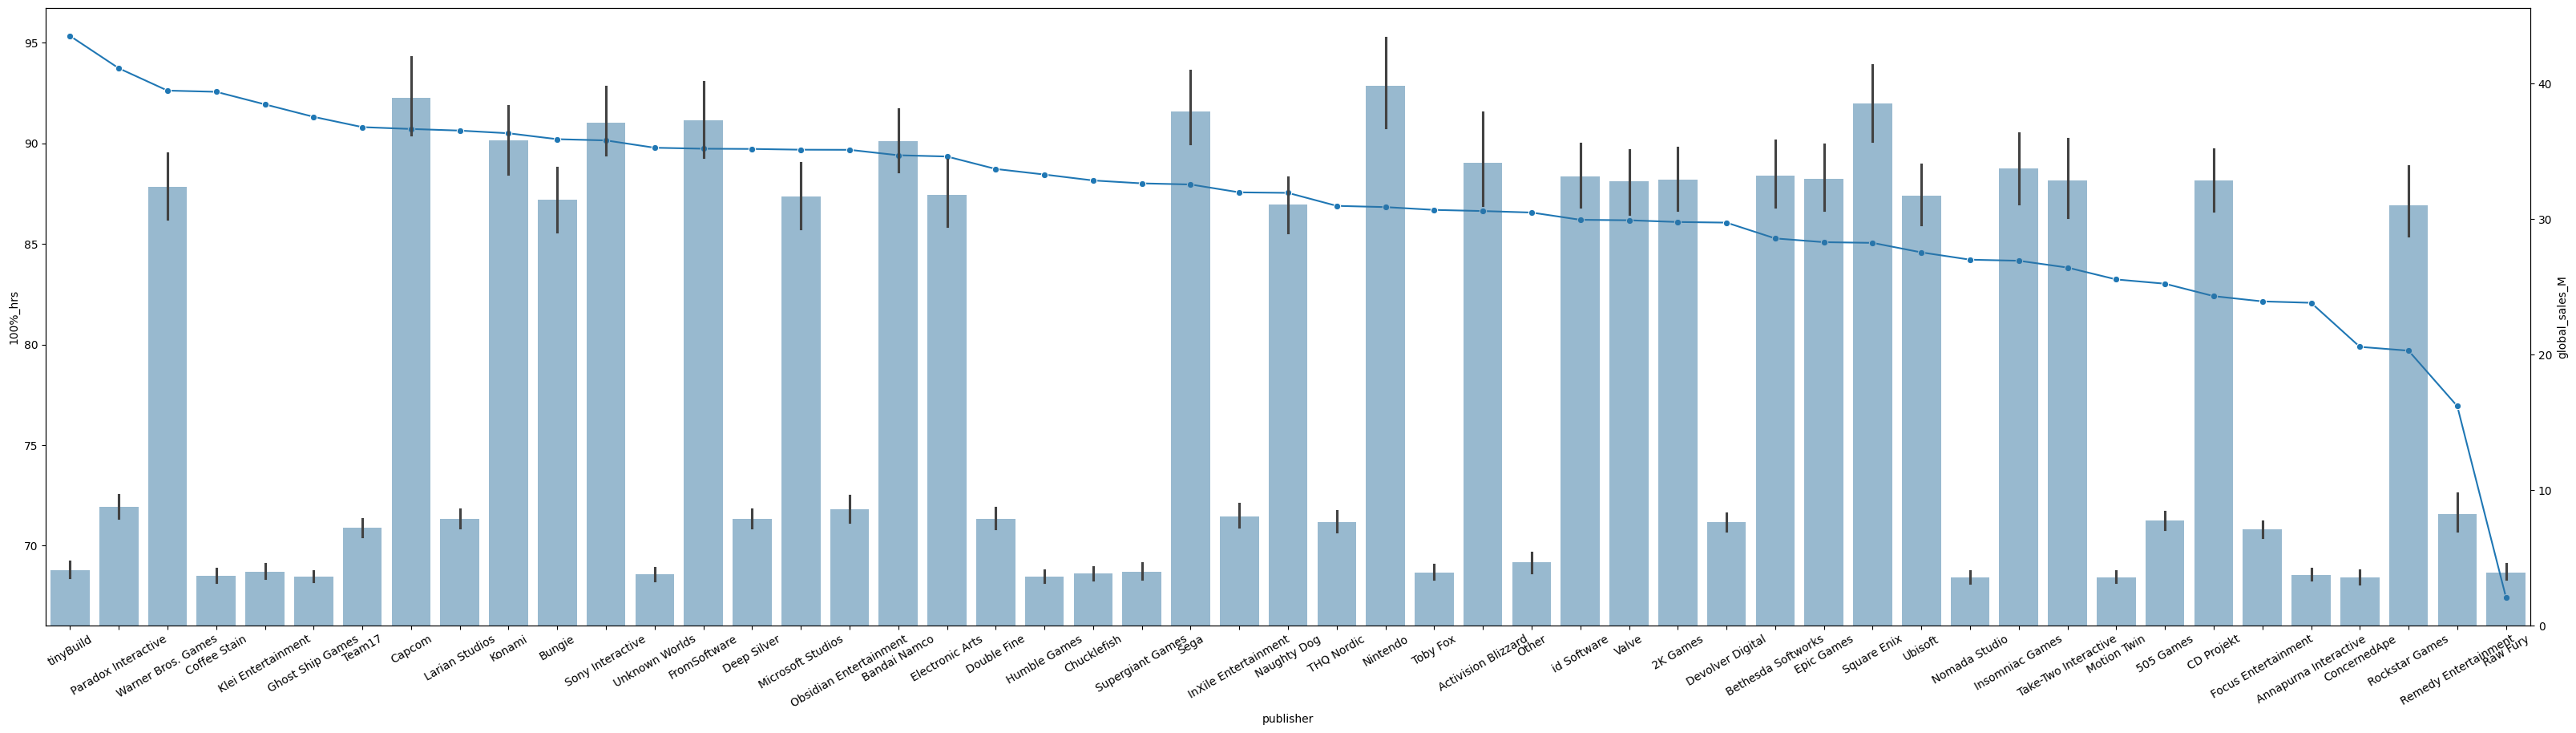

In [ ]:
#setting up and creating the line and bar chart on develper global sales vs the average time it takes to %100 the game
fig, ax1 = plt.subplots(figsize=(40,10))
plt.xticks(rotation=30)
sns.lineplot(data = gs['100%_hrs'], marker='o', sort = False, ax=ax1) #the line part of the chart
ax2 = ax1.twinx()

sns.barplot(data = df, x='publisher', y='global_sales_M', alpha=0.5, ax=ax2) #the bar part of the chart

The graph shows that how long it takes to complete the game does not affect how much the company makes in the global market.

Next, I would like to see how much the whole gaming industry made in the years.

<Axes: xlabel='year', ylabel='global_sales_M'>

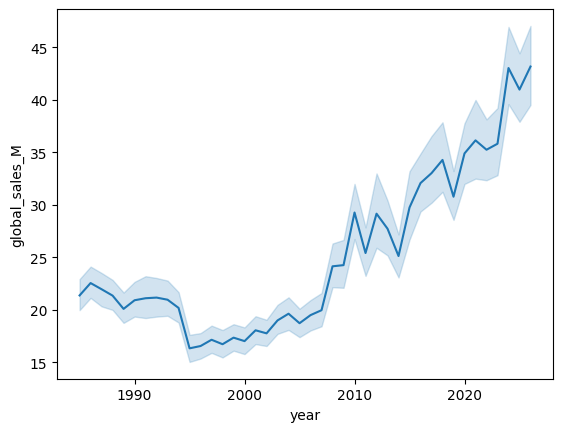

In [ ]:
#a line plot on how much the game indister made each year
sns.lineplot(data=df, x='year', y= 'global_sales_M')


The graph shows that, over the years, sales have been increasing quite a bit.

Next, I would like to compare the profits for each platform type.

First, I need to create a data frame containing the aggregated data I will use: year, platform type, and global sales.

In [ ]:
#creating a new data frame for a multi line plot comparing platfor type each year and how much they made globaly
ye = df.groupby(['year', 'platform_type'])['global_sales_M'].sum().reset_index()

Next, I need to create a pivot table so the graph has a separate line for each platform.

In [ ]:
#setting up a pivot table for the multi line plot
le = ye.pivot(index="year", columns="platform_type", values="global_sales_M")

Now it's time to make a graph showing how much each platform type made over the years, along with the games sold on each platform.

<Axes: xlabel='year'>

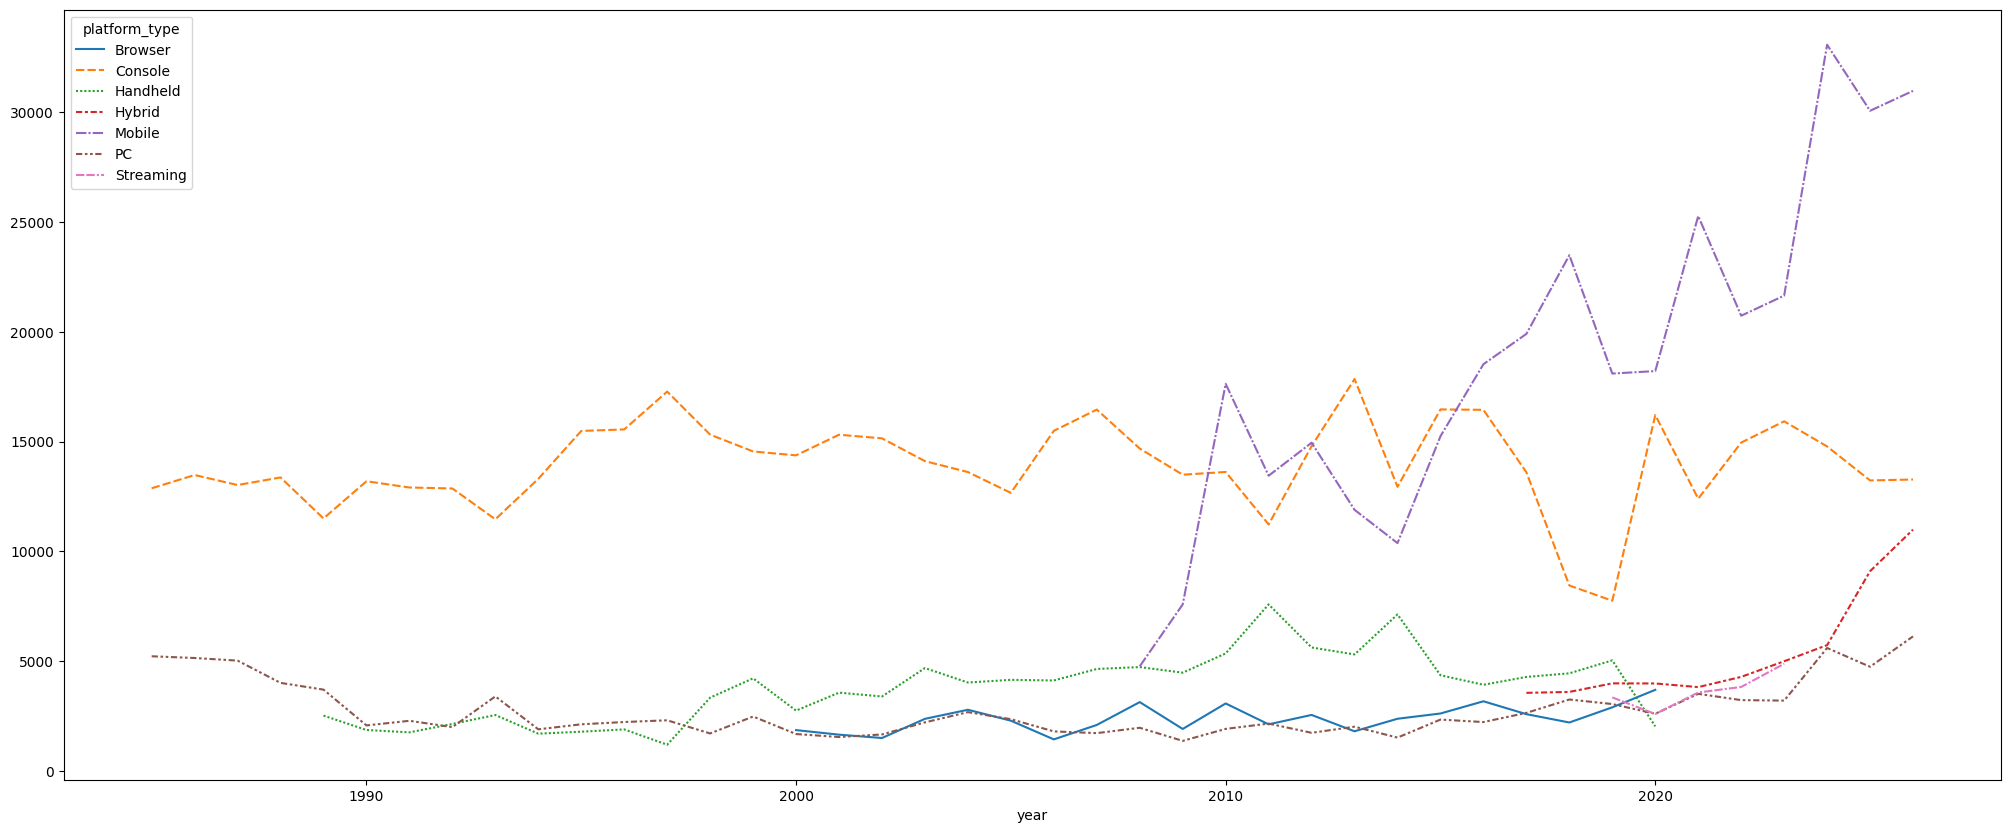

In [ ]:
#sizeing and showing the plot
plt.subplots(figsize=(25,10))
sns.lineplot(le)

The final thing I would like to look at is how the ESRB Rating compares to how people rate the games, and how many Game of the Year awards they nominated for and received.

In [ ]:
print(df.groupby('esrb_rating').agg({'title':'count','user_score':'mean', 'goty_nominated': 'sum','goty_won': 'sum','metacritic_score': 'mean'}).sort_values(by= 'title', ascending=False))

             title  user_score  goty_nominated  goty_won  metacritic_score
esrb_rating                                                               
T            14065    7.394732             631        89         73.978528
M            13924    7.416324             632       103         74.108805
E            12492    7.416250             562        85         74.106068
E10+          5984    7.402624             244        42         73.929646
Not Rated     3044    7.401084             140        16         74.060447
AO             491    7.439104              23         3         74.046843


In [ ]:
#transfering the cleaned data back to google big query
to_gbq(df,
       destination_table='Data.Games_Cleaned',
       project_id= 'capstone-2026-498917',
       if_exists='replace'
)


100%|██████████| 1/1 [00:00<00:00, 9020.01it/s]
